In [43]:
import matplotlib.pyplot as plt
import torch
import numpy as np

In [44]:
def f_grad(x):
    return 2*x + 4

In [45]:
def gradient_descent(lr, iterations=100):
    x = 10.0
    path = []
    for _ in range(iterations):
        path.append(x)
        x = x - lr * f_grad(x)
    return path

In [46]:
def plot():
    plt.figure(figsize=(10, 4.5))
    
    path = gradient_descent(0.01)
    plt.plot(path, label="eta = 0.01 (small)")
    plt.legend()
    plt.show()
    
    path = gradient_descent(0.1)
    plt.plot(path, label="eta = 0.1 (optimal)")
    plt.legend()
    plt.show()
    
    path = gradient_descent(1.1)
    plt.plot(path, label="eta = 1.1 (unstable)")
    plt.legend()
    plt.show()

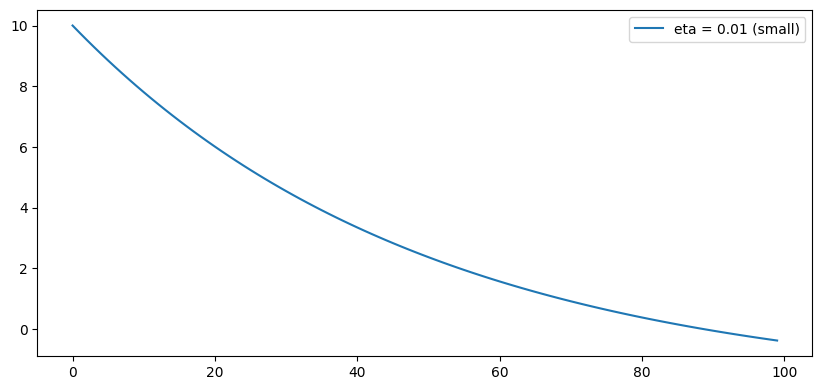

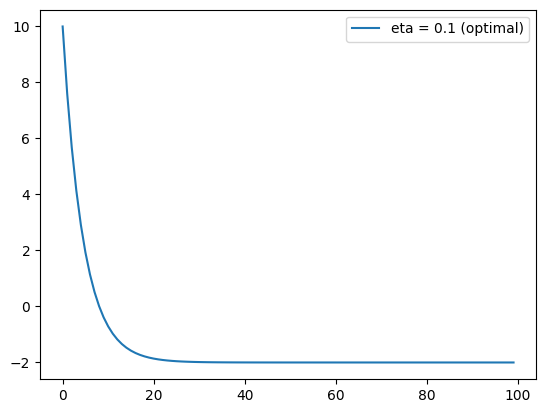

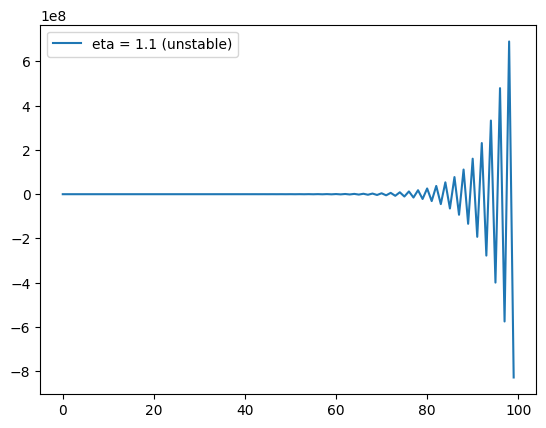

In [47]:
plot()

In [48]:
def loss_fn(x):
    return (
        0.05 * x**2
        + torch.sin(2*x)
        + 0.7 * torch.sin(5*x)
        + 0.3 * torch.sin(11*x)
    )

def jitter(val, eps=0.1):
    return val + np.random.uniform(-eps, eps)


In [49]:
def run_optimizer(optimizer_class, start_x, lr=0.01, steps=100):
    x = torch.tensor(start_x, requires_grad=True)
    optimizer = optimizer_class([x], lr=lr)

    for _ in range(steps):
        optimizer.zero_grad()
        loss = loss_fn(x)
        loss.backward()
        optimizer.step()

    return x.item()

In [50]:
points = np.linspace(-5, 5, 10)
res1 = []
res2 = []
res3 = []

In [51]:
for start in points:
    print(f"\nx = {start}")
    a = run_optimizer(torch.optim.SGD, start)
    print("SGD     :", a)
    res1.append(a)
    b = run_optimizer(torch.optim.RMSprop, start)
    print("RMSProp :", b)
    res2.append(b)
    c = run_optimizer(torch.optim.Adam, start)
    print("Adam    :", c)
    res3.append(c)


x = -5.0
SGD     : -5.276038567903184
RMSProp : -5.276038567903184
Adam    : -5.274807072685373

x = -3.888888888888889
SGD     : -4.1014388931419
RMSProp : -4.101438893141901
Adam    : -4.100653009414736

x = -2.7777777777777777
SGD     : -2.9769629332604013
RMSProp : -2.9769629332604013
Adam    : -2.9760082308165954

x = -1.6666666666666665
SGD     : -1.3250669396787855
RMSProp : -1.3250669396787853
Adam    : -1.3263177214736686

x = -0.5555555555555554
SGD     : -0.6167674140180961
RMSProp : -0.616766623839038
Adam    : -0.6169919086318573

x = 0.5555555555555554
SGD     : 0.45724789377306074
RMSProp : 0.46036147410945405
Adam    : 0.45687565958153387

x = 1.666666666666667
SGD     : 2.170319777513711
RMSProp : 2.170319777513711
Adam    : 2.169956201606512

x = 2.7777777777777786
SGD     : 2.1703197775137113
RMSProp : 2.1703197775137113
Adam    : 2.183036321778325

x = 3.8888888888888893
SGD     : 3.292867537002168
RMSProp : 3.2928675370021674
Adam    : 3.303924831351716

x = 5.0
S

In [52]:
xs = torch.linspace(-5, 5, 1000)
ys = loss_fn(xs)
global_min_x = xs[ys.argmin()].item()


In [53]:
def run_optimizer_final(optimizer_class, start_x, lr=0.01, steps=200):
    x = torch.tensor(start_x, requires_grad=True)
    opt = optimizer_class([x], lr=lr)

    for _ in range(steps):
        opt.zero_grad()
        loss = loss_fn(x)
        loss.backward()
        opt.step()

    return x.item()


In [54]:
starts = np.linspace(-5, 5, 15)

results = {"SGD": [], "RMSprop": [], "Adam": []}

for s in starts:
    results["SGD"].append(run_optimizer_final(torch.optim.SGD, s))
    results["RMSprop"].append(run_optimizer_final(torch.optim.RMSprop, s))
    results["Adam"].append(run_optimizer_final(torch.optim.Adam, s))


C:\Users\nisan\AppData\Local\Temp\ipykernel_7324\1244285400.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


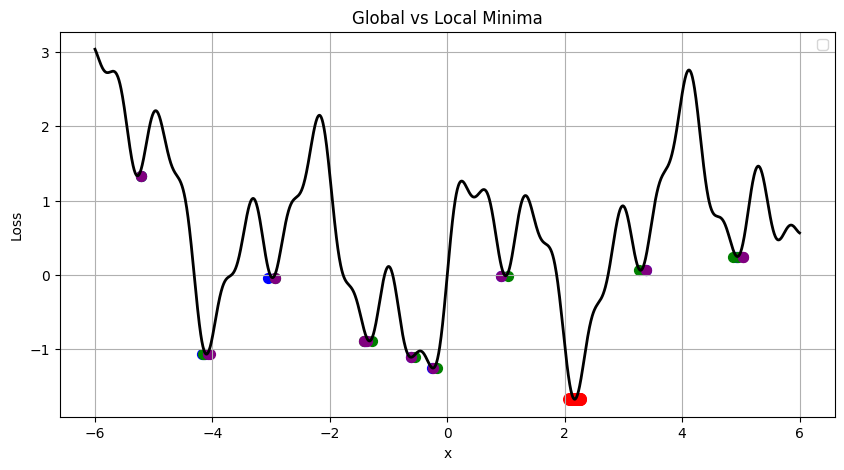

In [55]:
plt.figure(figsize=(10,5))

x_plot = np.linspace(-6, 6, 2000)
y_plot = loss_fn(torch.tensor(x_plot)).numpy()
plt.plot(x_plot, y_plot, color="black", linewidth=2)

for opt, color in zip(["SGD", "RMSprop", "Adam"],
                      ["blue", "green", "purple"]):
    for x in results[opt]:
        y = loss_fn(torch.tensor(x)).item()
        if abs(x - global_min_x) < 0.2:
            plt.scatter(jitter(x), y, color="red", s=70)
        else:
            plt.scatter(jitter(x), y, color=color, s=50)

plt.xlabel("x")
plt.ylabel("Loss")
plt.title("Global vs Local Minima")
plt.grid(True)
plt.legend()
plt.show()
